In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pyimfit
from euclid_sbf_pipeline import imdisplay

In [28]:
hdul = fits.open('Euclid/data/FornaxLSB/FCC148/flt/FCC148.fits')
hdul.info()

data = hdul[0].data
header = hdul[0].header
hdul.close()

Filename: Euclid/data/FornaxLSB/FCC148/flt/FCC148.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     186   (1657, 1657)   float32   


In [3]:
from photutils.isophote import EllipseGeometry
from mgefit.find_galaxy import find_galaxy

nonandata = np.where(np.isnan(data), np.nanmedian(data), data)
f = find_galaxy(nonandata, quiet=True)
geometry = EllipseGeometry(x0=f.ypeak, y0=f.xpeak, 
                            sma=f.majoraxis, eps=f.eps, 
                            pa=(90+f.pa)*np.pi/180, astep=0.1)
print((geometry.x0, geometry.y0), geometry.sma, geometry.sma*(1-geometry.eps), geometry.pa, geometry.eps)

(np.int64(824), np.int64(827)) 535.3747189039884 201.09217993060702 3.145225145692081 0.6243898472787806


In [26]:
hdul = fits.open('Euclid/data/FornaxLSB/FCC146/flt/FCC146.fits')
hdul.info()

data = hdul[0].data
header = hdul[0].header
hdul.close()

Filename: Euclid/data/FornaxLSB/FCC146/flt/FCC146.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     186   (279, 279)   float32   


In [10]:
from photutils.isophote import EllipseGeometry
from mgefit.find_galaxy import find_galaxy

nonandata = np.where(np.isnan(data), np.nanmedian(data), data)
f = find_galaxy(nonandata, quiet=True)
geometry = EllipseGeometry(x0=f.ypeak, y0=f.xpeak, 
                            sma=f.majoraxis, eps=f.eps, 
                            pa=(90+f.pa)*np.pi/180, astep=0.1)
print((geometry.x0, geometry.y0), geometry.sma, geometry.sma*(1-geometry.eps), geometry.pa, geometry.eps)
print(geometry.pa*180/np.pi)

(np.int64(147), np.int64(143)) 77.17370801108554 40.76205080271131 2.6947187743306467 0.47181427647799323
154.39601274381218


In [21]:
imageFile = "Euclid/data/FornaxLSB/FCC148/flt/FCC148.fits"
imfitConfigFile = "pyimfit_config.dat"

# read in image data, convert to proper double-precisions, little-endian format
image_data = fits.getdata(imageFile)
original_sky = 12.407449722290039
mask = np.isnan(image_data)
image_data -= original_sky
# image_data += np.min(image_data)

# construct model from config file; construct new Imfit fitter based on model,;
model_desc = pyimfit.ModelDescription.load(imfitConfigFile)

# create an Imfit object, using the previously loaded model configuration
imfit_fitter = pyimfit.Imfit(model_desc, zeroPoint=30.132)

# load the image data and image characteristics and do a standard fit
# (using default chi^2 statistics and Levenberg-Marquardt solver)
result = imfit_fitter.fit(image_data, gain=21.75762484773, read_noise=6, original_sky=original_sky) # mask=mask)

# check the fit and print the resulting best-fit parameter values
if result.fitConverged is True:
    print("Fit converged: chi^2 = {0}, reduced chi^2 = {1}".format(imfit_fitter.fitStatistic, result.fitStatReduced))
    bestfit_params = result.params
    print("Best-fit parameter values:", bestfit_params)

Fit converged: chi^2 = 19992588.966790106, reduced chi^2 = 7.5376206246894695
Best-fit parameter values: [8.35614638e+02 8.29201610e+02 9.00675681e+01 5.87564386e-01
 1.59855759e+00 8.65493087e+01 1.79082881e+02]


In [22]:
for p,perr in zip(result.params,result.paramErrs):
    print(p,perr)


835.6146378076073 0.012847618104002622
829.2016100167991 0.0047154366340145595
90.06756805802057 0.003234955932650526
0.5875643855107191 4.7765444263157675e-05
1.5985575933738039 0.000404394486977502
86.54930872461004 0.022647770885884915
179.08288091185693 0.023342952134579115


In [23]:
model_dict = imfit_fitter.getModelAsDict()
print(model_dict)

bestfit_model_im = imfit_fitter.getModelImage()

{'function_sets': [{'X0': [835.6146378076073, 799.0, 849.0], 'Y0': [829.2016100167991, 802.0, 852.0], 'function_list': [{'name': 'Sersic', 'label': '', 'parameters': {'PA': [90.06756805802057, 0.0, 100.0], 'ell': [0.5875643855107191, 0.0, 1.0], 'n': [1.5985575933738039, 0.0, 5.0], 'I_e': [86.54930872461004, 0.0, 500.0], 'r_e': [179.08288091185693, 50.0, 400.0]}}]}], 'options': OrderedDict({'GAIN': 21.75762484773, 'READNOISE': 6, 'ORIGINAL_SKY': 12.407449722290039})}


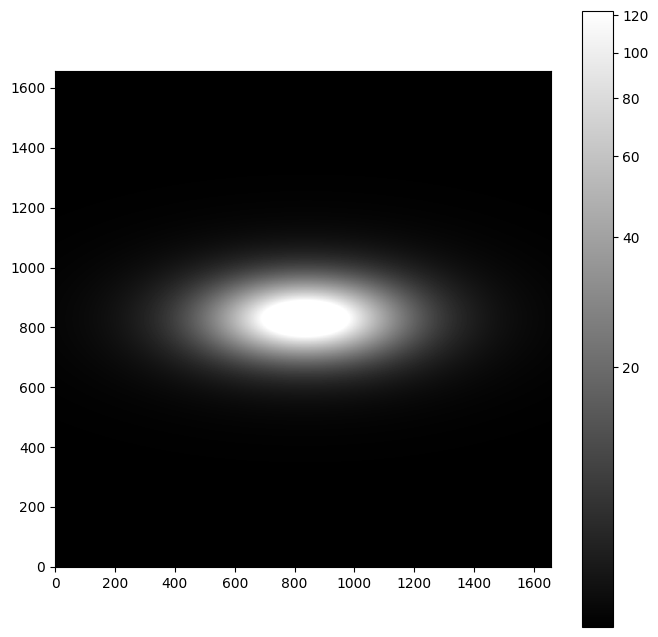

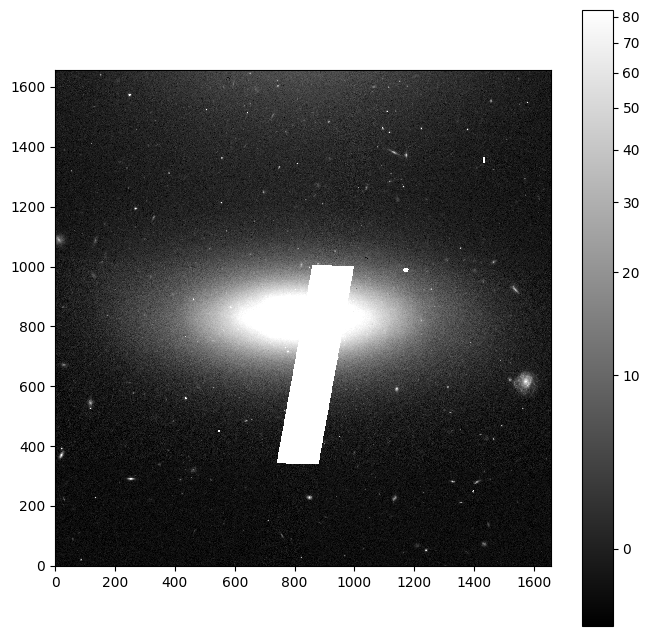

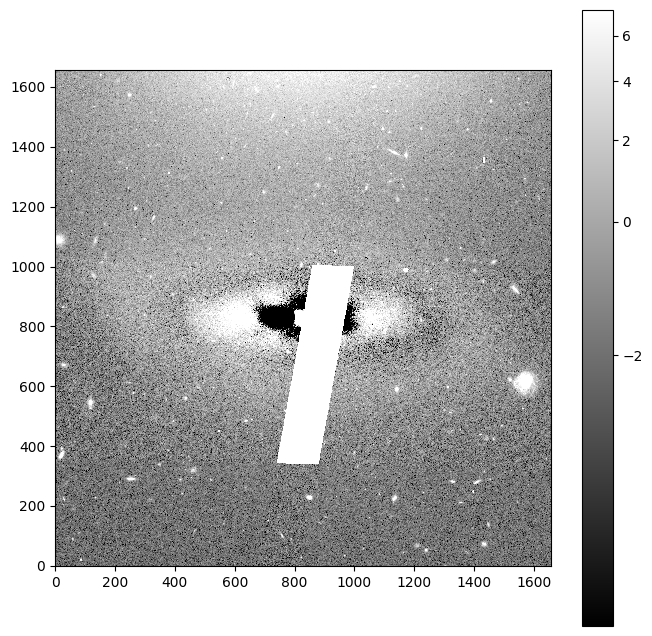

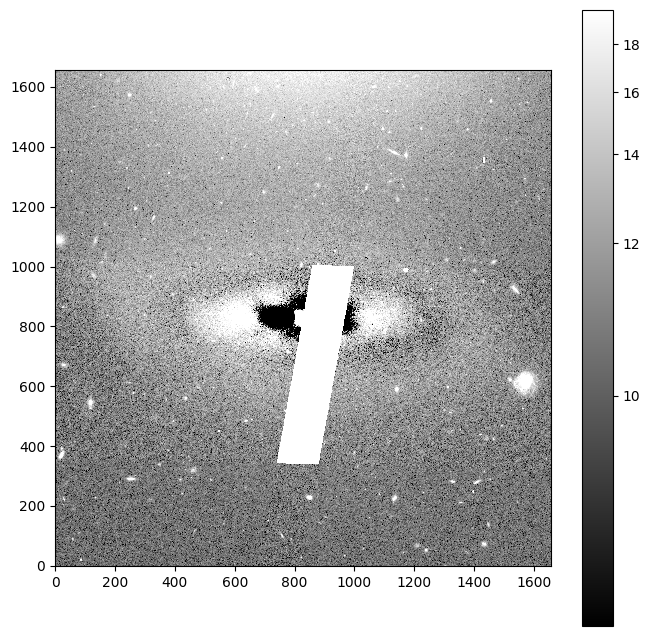

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
imdisplay(bestfit_model_im, ax, percentlow=1, percenthigh=99, scale='asinh')
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
imdisplay(image_data, ax, percentlow=1, percenthigh=99, scale='asinh')
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
imdisplay(image_data-bestfit_model_im, ax, percentlow=1, percenthigh=99, scale='asinh')
plt.show()

In [30]:
imageFile = "Euclid/data/FornaxLSB/FCC146/flt/FCC146.fits"
imfitConfigFile = "pyimfit_config146.dat"

# read in image data, convert to proper double-precisions, little-endian format
image_data = fits.getdata(imageFile)
original_sky = 10.274806022644043
mask = np.isnan(image_data)
image_data -= original_sky
# image_data += np.min(image_data)

# construct model from config file; construct new Imfit fitter based on model,;
model_desc = pyimfit.ModelDescription.load(imfitConfigFile)

# create an Imfit object, using the previously loaded model configuration
imfit_fitter = pyimfit.Imfit(model_desc, zeroPoint=30.132)

# load the image data and image characteristics and do a standard fit
# (using default chi^2 statistics and Levenberg-Marquardt solver)
result = imfit_fitter.fit(image_data, gain=21.75762484773, read_noise=6, original_sky=original_sky) # mask=mask)

# check the fit and print the resulting best-fit parameter values
if result.fitConverged is True:
    print("Fit converged: chi^2 = {0}, reduced chi^2 = {1}".format(imfit_fitter.fitStatistic, result.fitStatReduced))
    bestfit_params = result.params
    print("Best-fit parameter values:", bestfit_params)

Fit converged: chi^2 = 168399.84596254205, reduced chi^2 = 2.2190576370775625
Best-fit parameter values: [147.         144.26736264  66.54983752   0.46140822   0.67897506
   1.66388199  53.13489915]


In [31]:
for p,perr in zip(result.params,result.paramErrs):
    print(p,perr)

model_dict = imfit_fitter.getModelAsDict()
print(model_dict)

bestfit_model_im = imfit_fitter.getModelImage()

147.0 0.0
144.26736263822318 0.12272199018690905
66.54983752192042 0.33355931420346296
0.4614082181042999 0.004130813382271392
0.6789750579584614 0.008935982455036488
1.6638819875087285 0.016690239227764005
53.13489914525089 0.3474952142575366
{'function_sets': [{'X0': [147.0, 147.0, 849.0], 'Y0': [144.26736263822318, 143.0, 852.0], 'function_list': [{'name': 'Sersic', 'label': '', 'parameters': {'PA': [66.54983752192042, 0.0, 185.0], 'ell': [0.4614082181042999, 0.0, 1.0], 'n': [0.6789750579584614, 0.0, 5.0], 'I_e': [1.6638819875087285, 0.0, 500.0], 'r_e': [53.13489914525089, 5.0, 200.0]}}]}], 'options': OrderedDict({'GAIN': 21.75762484773, 'READNOISE': 6, 'ORIGINAL_SKY': 10.274806022644043})}


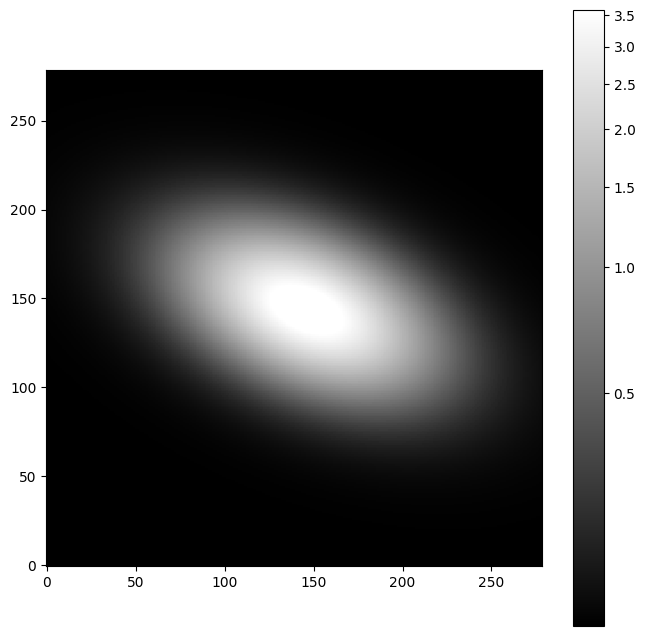

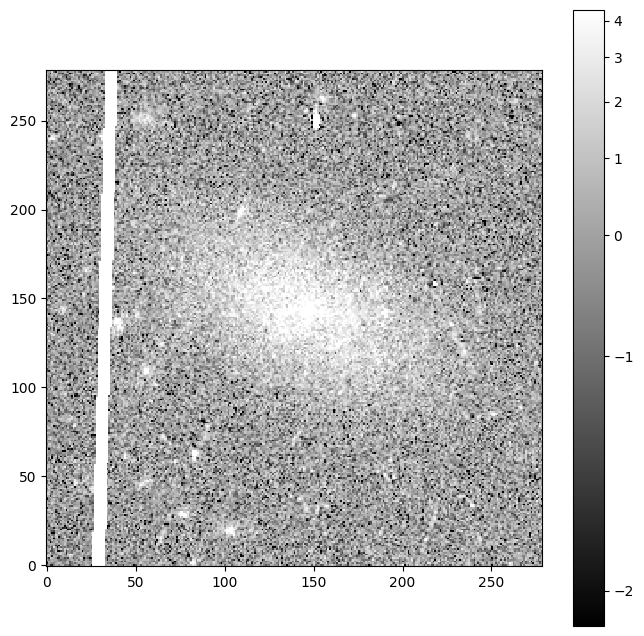

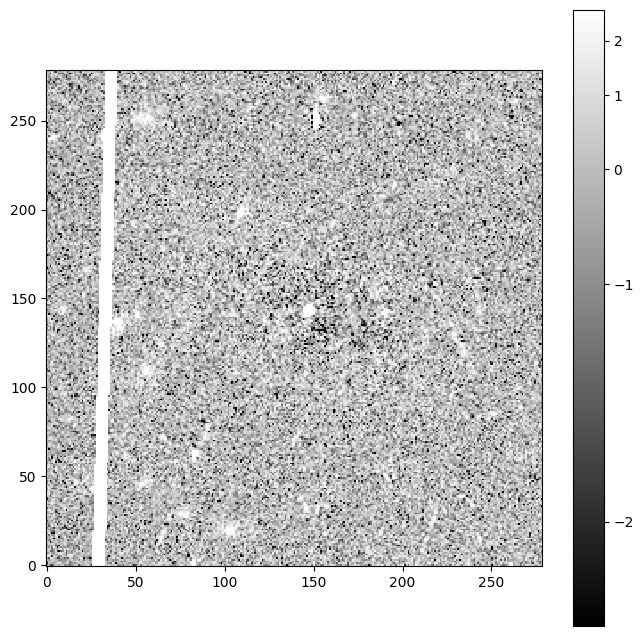

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))
imdisplay(bestfit_model_im, ax, percentlow=1, percenthigh=99, scale='asinh')
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
imdisplay(image_data, ax, percentlow=1, percenthigh=99, scale='asinh')
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
imdisplay(image_data-bestfit_model_im, ax, percentlow=1, percenthigh=99, scale='asinh')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pyimfit
from euclid_sbf_pipeline import imdisplay

In [34]:
hdul = fits.open('Euclid/data/FornaxH/FCC146/flt/FCC146.fits')
hdul.info()

data = hdul[0].data
header = hdul[0].header
hdul.close()

Filename: Euclid/data/FornaxH/FCC146/flt/FCC146.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     186   (93, 93)   float32   


In [35]:
from photutils.isophote import EllipseGeometry
from mgefit.find_galaxy import find_galaxy

nonandata = np.where(np.isnan(data), np.nanmedian(data), data)
f = find_galaxy(nonandata, quiet=True)
geometry = EllipseGeometry(x0=f.ypeak, y0=f.xpeak, 
                            sma=f.majoraxis, eps=f.eps, 
                            pa=(90+f.pa)*np.pi/180, astep=0.1)
print((geometry.x0, geometry.y0), geometry.sma, geometry.sma*(1-geometry.eps), geometry.pa, geometry.eps)

(np.int64(49), np.int64(47)) 24.663795119129983 12.686228925494326 2.66807256604753 0.48563354243668266


In [ ]:
imageFile = "Euclid/data/FornaxH/FCC146/flt/FCC146.fits"
imfitConfigFile = "pyimfit_config2.dat"

# read in image data, convert to proper double-precisions, little-endian format
image_data = fits.getdata(imageFile)
original_sky = 10.274806022644043
mask = np.isnan(image_data)
image_data -= original_sky
# image_data += np.min(image_data)

# construct model from config file; construct new Imfit fitter based on model,;
model_desc = pyimfit.ModelDescription.load(imfitConfigFile)

# create an Imfit object, using the previously loaded model configuration
imfit_fitter = pyimfit.Imfit(model_desc, zeroPoint=30)

# load the image data and image characteristics and do a standard fit
# (using default chi^2 statistics and Levenberg-Marquardt solver)
result = imfit_fitter.fit(image_data, gain=21.75762484773, read_noise=6, original_sky=original_sky) # mask=mask)

# check the fit and print the resulting best-fit parameter values
if result.fitConverged is True:
    print("Fit converged: chi^2 = {0}, reduced chi^2 = {1}".format(imfit_fitter.fitStatistic, result.fitStatReduced))
    bestfit_params = result.params
    print("Best-fit parameter values:", bestfit_params)

Fit converged: chi^2 = 19992588.966790106, reduced chi^2 = 7.5376206246894695
Best-fit parameter values: [8.35614638e+02 8.29201610e+02 9.00675681e+01 5.87564386e-01
 1.59855759e+00 8.65493087e+01 1.79082881e+02]


In [ ]:
for p,perr in zip(result.params,result.paramErrs):
    print(p,perr)


835.6146378076073 0.012847618104002622
829.2016100167991 0.0047154366340145595
90.06756805802057 0.003234955932650526
0.5875643855107191 4.7765444263157675e-05
1.5985575933738039 0.000404394486977502
86.54930872461004 0.022647770885884915
179.08288091185693 0.023342952134579115


In [ ]:
model_dict = imfit_fitter.getModelAsDict()
print(model_dict)

bestfit_model_im = imfit_fitter.getModelImage()

{'function_sets': [{'X0': [835.6146378076073, 799.0, 849.0], 'Y0': [829.2016100167991, 802.0, 852.0], 'function_list': [{'name': 'Sersic', 'label': '', 'parameters': {'PA': [90.06756805802057, 0.0, 100.0], 'ell': [0.5875643855107191, 0.0, 1.0], 'n': [1.5985575933738039, 0.0, 5.0], 'I_e': [86.54930872461004, 0.0, 500.0], 'r_e': [179.08288091185693, 50.0, 400.0]}}]}], 'options': OrderedDict({'GAIN': 21.75762484773, 'READNOISE': 6, 'ORIGINAL_SKY': 12.407449722290039})}


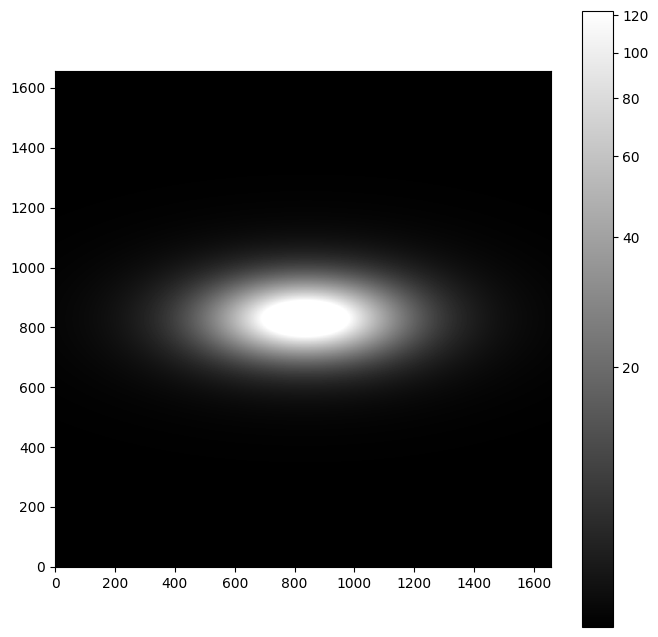

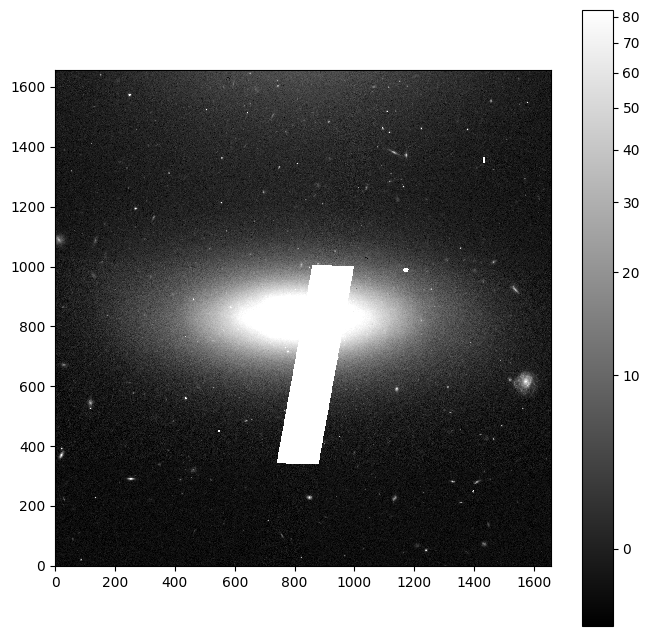

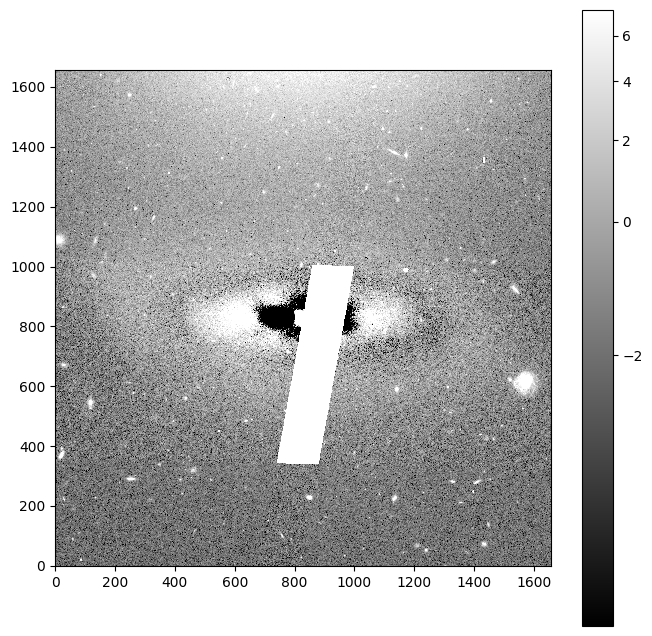

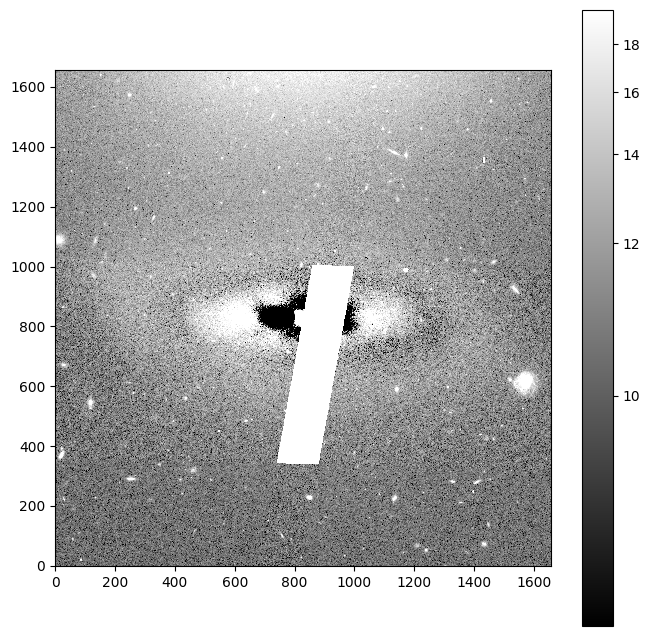

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
imdisplay(bestfit_model_im, ax, percentlow=1, percenthigh=99, scale='asinh')
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
imdisplay(image_data, ax, percentlow=1, percenthigh=99, scale='asinh')
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
imdisplay(image_data-bestfit_model_im, ax, percentlow=1, percenthigh=99, scale='asinh')
plt.show()